<a href="https://colab.research.google.com/github/scottspurlock/csc4466-s2026/blob/main/tutorials/day17_tutorial_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSC 4466 Computer Vision
## Day 17 Tutorial - Artifical Neural Networks with Tensorflow
Adapted from:
- Tensorflow image classification tutorial https://www.tensorflow.org/tutorials/images/classification
- Practical Machine Learning for Computer Vision by Lakshmanan


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


## Get the data

In [2]:
# flowers: 'https://drive.google.com/uc?export=download&id=1clO8535JBBW2Ye1V6KVpDQJk2Baioq8_'

# Download and unzip flowers.zip file.
# Should create 3 folders.

import gdown
gdown.download(id='1clO8535JBBW2Ye1V6KVpDQJk2Baioq8_', quiet=False)
!unzip flowers.zip


Downloading...
From: https://drive.google.com/uc?id=1clO8535JBBW2Ye1V6KVpDQJk2Baioq8_
To: /content/flowers.zip
100%|██████████| 10.4M/10.4M [00:00<00:00, 26.9MB/s]


Archive:  flowers.zip
replace flowers/bluebell/image_0241.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: flowers/bluebell/image_0241.jpg  
  inflating: flowers/bluebell/image_0242.jpg  
  inflating: flowers/bluebell/image_0243.jpg  
  inflating: flowers/bluebell/image_0244.jpg  
  inflating: flowers/bluebell/image_0245.jpg  
  inflating: flowers/bluebell/image_0246.jpg  
  inflating: flowers/bluebell/image_0247.jpg  
  inflating: flowers/bluebell/image_0248.jpg  
  inflating: flowers/bluebell/image_0249.jpg  
  inflating: flowers/bluebell/image_0250.jpg  
  inflating: flowers/bluebell/image_0251.jpg  
  inflating: flowers/bluebell/image_0252.jpg  
  inflating: flowers/bluebell/image_0253.jpg  
  inflating: flowers/bluebell/image_0254.jpg  
  inflating: flowers/bluebell/image_0255.jpg  
  inflating: flowers/bluebell/image_0256.jpg  
  inflating: flowers/bluebell/image_0257.jpg  
  inflating: flowers/bluebell/image_0258.jpg  
  inflating: flowers/bluebell/image_0259.jpg  
  in

## Visualize an example image

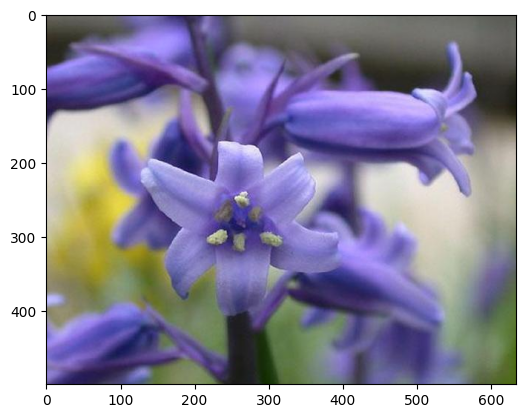

In [3]:
bgr = cv2.imread('flowers/bluebell/image_0241.jpg')
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
plt.imshow(rgb)
plt.show()

# Set some parameters
We'll process images in batches of 32 at a time, and we'll resize each image to 180 x 180.

In [4]:
batch_size = 32
img_height = 180
img_width = 180


In [5]:
# This is the folder where our images are
data_dir = 'flowers'

# Tensorflow will choose some of the images as training data
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.25,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 240 files belonging to 3 classes.
Using 180 files for training.


In [6]:
# Tensorflow will chooose the rest of the images as validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.25,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 240 files belonging to 3 classes.
Using 60 files for validation.


In [7]:
# The class names (the names of the different types of images) are
# automatically inferred from the folder names.
class_names = train_ds.class_names
print(class_names)


['bluebell', 'daisy', 'sunflower']


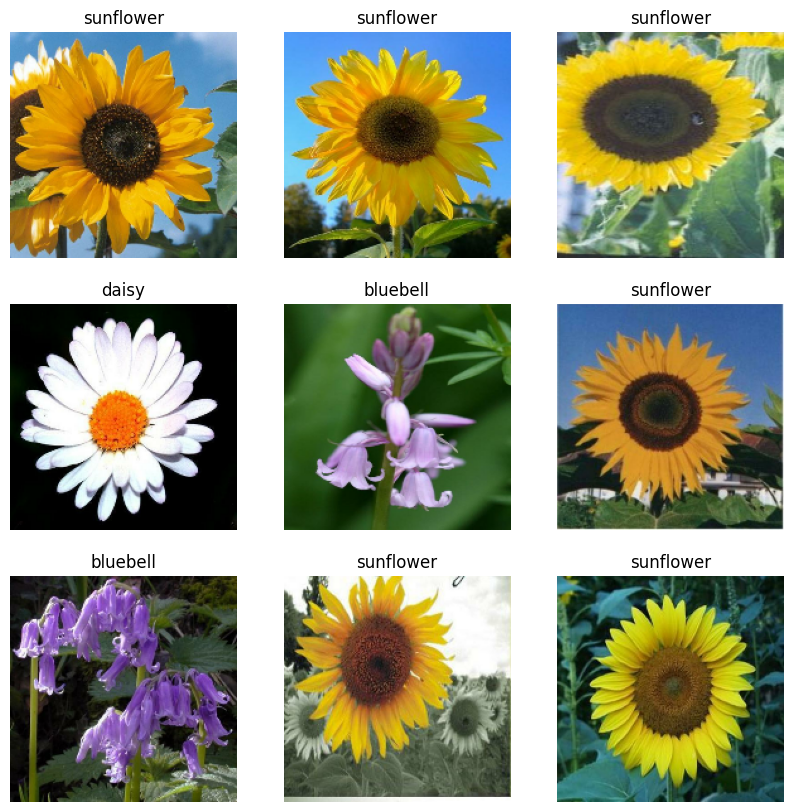

In [8]:
# The Tensorflow train_ds object makes it easy to get to the images and
# visualize them
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")


## Set a few values to make performance better for loading images

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


## Create the neural network (model)

In [10]:
num_classes = len(class_names)

# The model will first normalize the pixel values into the range 0-1.
# Then flatten the images so each is a long vector of numbers.
# Then connect that to a hidden (Dense) layer with 32 neurons.
# Then create 3 outputs, one per class.
model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(num_classes)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# Compiling the model gets it ready to train.
# We tell it which optimizer to use to find the best weights (Adam),
# What the learning rate is (how big a step to take while optimizing),
# and what loss function to use, and what metrics to keep track of (accuracy).
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [12]:
# Print out a summary of the layers of the model.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 97200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,220,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,221,059 (23.73 MB)

 Trainable params: 6,221,059 (23.73 MB)

 Non-trainable params: 0 (0.00 B)

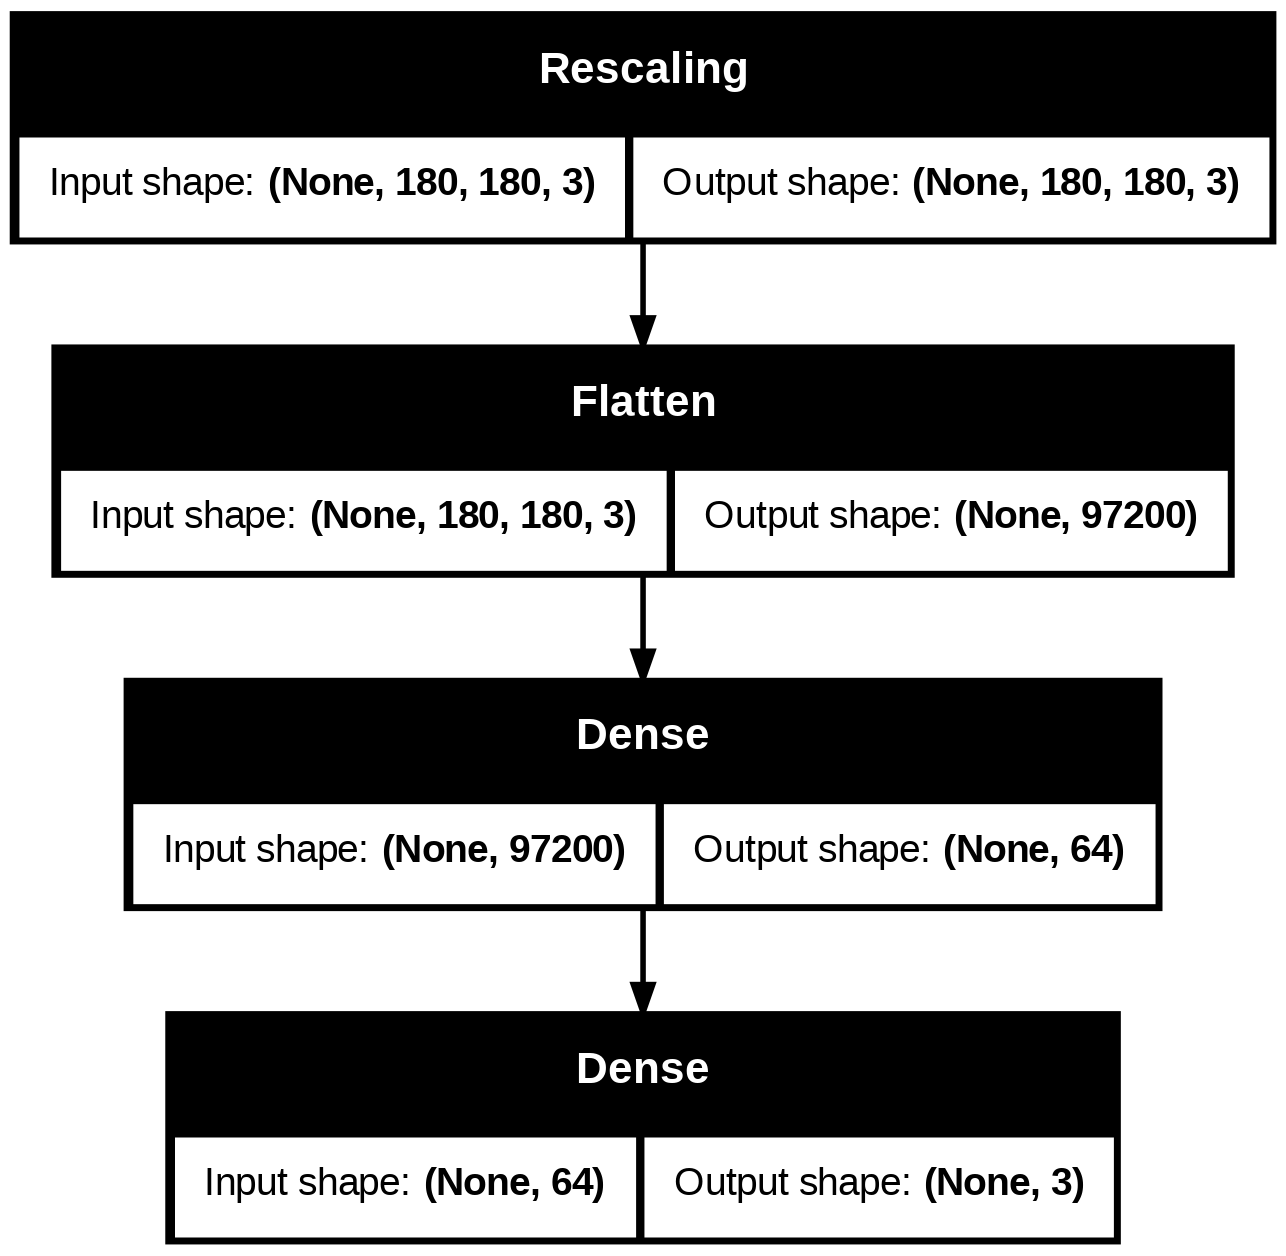

In [13]:
# Visualize the layers of the model.
# (None, 180, 180, 3) means that the model can handle various numbers of images,
# but they all have to be 180x180 and have 3 color channels.
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=False)

## Train (fit) the model
An epoch is one iteration of training, where the model sees each training example one time.

In [14]:
epochs=40
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)


Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 0.5389 - loss: 16.9665 - val_accuracy: 0.6333 - val_loss: 5.8304
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7278 - loss: 4.7724 - val_accuracy: 0.9167 - val_loss: 0.4429
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9222 - loss: 0.9546 - val_accuracy: 0.9667 - val_loss: 0.6565
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9278 - loss: 0.4208 - val_accuracy: 0.9667 - val_loss: 0.4331
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9611 - loss: 0.3929 - val_accuracy: 0.9000 - val_loss: 0.8234
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9778 - loss: 0.1532 - val_accuracy: 0.9333 - val_loss: 0.2657
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9778 - loss: 0.2113 - val_accuracy: 0.9667 - val_loss: 0.4805
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9778 - loss: 0.1424 - val_accuracy: 0.8833 - val_loss: 1.2723
Epo

## Visualize the results

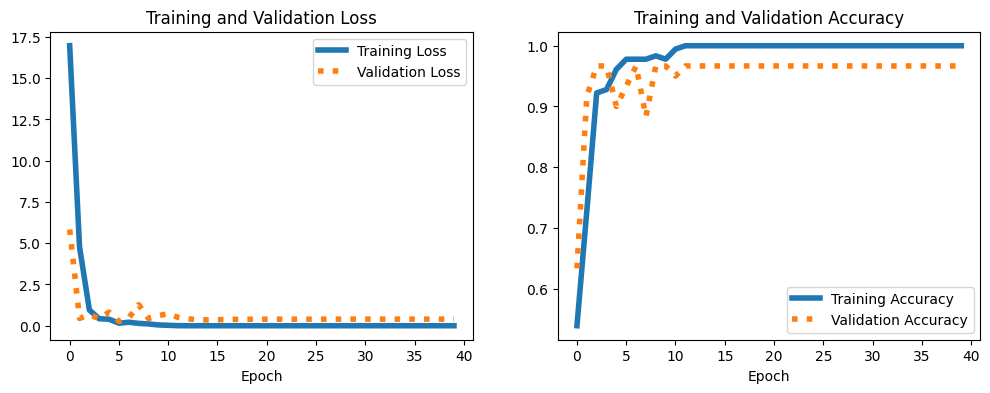

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, '-', label='Training Loss', linewidth=4)
plt.plot(epochs_range, val_loss, ':', label='Validation Loss', linewidth=4)
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, '-', label='Training Accuracy', linewidth=4)
plt.plot(epochs_range, val_acc, ':', label='Validation Accuracy', linewidth=4)
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

## Download a new image and predict it with the trained model.

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1284k  100 1284k    0     0  11.4M      0 --:--:-- --:--:-- --:--:-- 11.5M


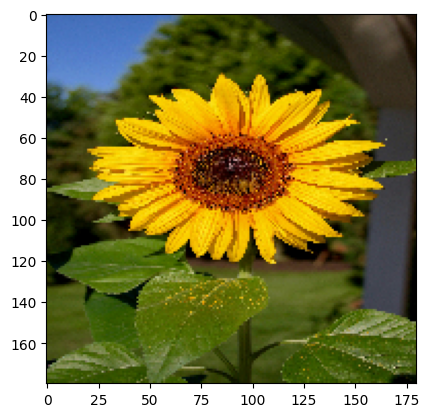

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
Predictions:
[[-28.478737   -0.8945888  54.351154 ]]
Probabilities:
tf.Tensor([1.0652061e-36 1.0164330e-24 1.0000000e+00], shape=(3,), dtype=float32)
This image most likely belongs to sunflower with a 100.00 percent confidence.


In [16]:
url = 'https://images.unsplash.com/photo-1566669086984-077347c1f4bb?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&auto=format&fit=crop&w=679&q=80'

!curl -o download.png {url}
img = cv2.imread('download.png')
img = cv2.resize(img, (img_width, img_height))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

# Reshape it so that it is 1 x h x w x 3
# (The first 1 puts the image in a batch of size 1)
img_array = np.reshape(img, (1, img_height, img_width, 3))

# Predict the image with the model
predictions = model.predict(img_array)
print('Predictions:')
print(predictions)

# Use softmax to convert the scores coming out of the neural network
# into probabilities (sum to 1)
score = tf.nn.softmax(predictions[0])
print('Probabilities:')
print(score)

# Figure out which class is predicted based on the highest probability
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)


# What if the image doesn't look like any of the training examples? The model will still try to make a prediction.

--2026-04-02 14:25:33--  https://drive.google.com/uc?export=download&id=1k-uhoC1gotg48RJlFffNp6B7brLmxFGq
Resolving drive.google.com (drive.google.com)... 142.250.4.138, 142.250.4.139, 142.250.4.113, ...
Connecting to drive.google.com (drive.google.com)|142.250.4.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1k-uhoC1gotg48RJlFffNp6B7brLmxFGq&export=download [following]
--2026-04-02 14:25:33--  https://drive.usercontent.google.com/download?id=1k-uhoC1gotg48RJlFffNp6B7brLmxFGq&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.10.132, 2404:6800:4003:c0f::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.10.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 549782 (537K) [image/jpeg]
Saving to: ‘download.jpg’

download.jpg        100%[===================>] 536.90K  --.-KB/s    in 0.006s  

2026

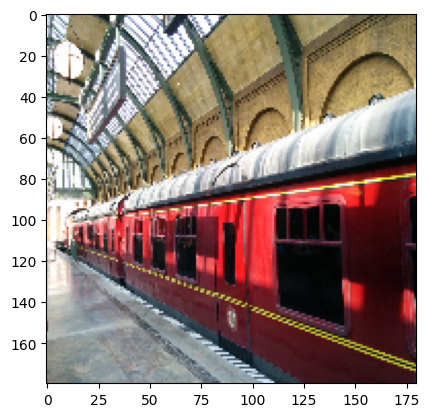

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predictions:
[[37.08568   -2.8773537 18.724684 ]]
Probabilities:
tf.Tensor([1.0000000e+00 4.4083474e-18 1.0615037e-08], shape=(3,), dtype=float32)
This image most likely belongs to bluebell with a 100.00 percent confidence.


In [17]:
# url = 'https://drive.google.com/uc?export=download&id=1k-uhoC1gotg48RJlFffNp6B7brLmxFGq'
! wget -O download.jpg 'https://drive.google.com/uc?export=download&id=1k-uhoC1gotg48RJlFffNp6B7brLmxFGq'

img = cv2.imread('download.jpg')
img = cv2.resize(img, (img_width, img_height))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.show()

# Reshape it so that it is 1 x h x w x 3
# (The first 1 puts the image in a batch of size 1)
img_array = np.reshape(img, (1, img_height, img_width, 3))

# Predict the image with the model
predictions = model.predict(img_array)
print('Predictions:')
print(predictions)

# Use softmax to convert the scores coming out of the neural network
# into probabilities (sum to 1)
score = tf.nn.softmax(predictions[0])
print('Probabilities:')
print(score)

# Figure out which class is predicted based on the highest probability
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

